<a href="https://colab.research.google.com/github/Ankit-K-Jha/CNN_Cat_Dog_DL/blob/main/CNN_cat_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1:

***Importing all the Libraries.***

In [1]:
import tensorflow as tf
import numpy as np; import matplotlib.pyplot as mp; import sklearn; import seaborn as sns; from PIL import Image


In [2]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


***Loading Dataset*** through Kaggle

In [3]:
import json

kaggle = {
    "username": "Ankit_CUJ14",
    "key": "KGAT_f13e8b7d0281affa731690c17ddfd91e"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle, f)

Configuring kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install kaggle

In [6]:
!kaggle datasets list -s "cats and dogs"

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          17619        148                1  
mmoreaux/audio-cats-and-dogs                               Audio Cats and Dogs                                  101721956  2017-10-05 09:40:26.727000          19531        289        0.7647059  
mahmudulhaqueshawon/catcat                                 Cats and Dogs Classification                          65949527  2024-04-23 18:04:47.937000           3365        126            0.875  
samuelcortinhas/cats-and-

***Downloading*** dataset

In [7]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:08<00:00, 102MB/s]



In [8]:
!ls /content

kaggle.json  microsoft-catsvsdogs-dataset.zip  sample_data


***Unzipping*** dataset

In [9]:
import zipfile

zip_path = "/content/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
import os

print(os.listdir("/content/dataset"))

['readme[1].txt', 'MSR-LA - 3467.docx', 'PetImages']


In [11]:
import os

print(os.listdir("/content/dataset/PetImages"))

['Dog', 'Cat']


In [12]:
cat_path = "/content/dataset/PetImages/Cat"
dog_path = "/content/dataset/PetImages/Dog"

print("Cat Images :", len(os.listdir(cat_path)))
print("Dog Images :", len(os.listdir(dog_path)))

Cat Images : 12501
Dog Images : 12501


Part 2: Dataset Loading + Preprocessing + Data Augmentation

Removing Corrupted Images

In [13]:
import os

dataset_path = "/content/dataset/PetImages"

empty_files = []

for category in ["Cat", "Dog"]:
    folder = os.path.join(dataset_path, category)

    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)

        if os.path.isfile(file_path):
            size = os.path.getsize(file_path)

            if size == 0:
                empty_files.append(file_path)

print("Empty files found:", len(empty_files))

for file_path in empty_files:
    print(file_path)

Empty files found: 2
/content/dataset/PetImages/Cat/666.jpg
/content/dataset/PetImages/Dog/11702.jpg


In [14]:
for file_path in empty_files:
    os.remove(file_path)

print("Empty files deleted:", len(empty_files))

Empty files deleted: 2


In [15]:
import os
import tensorflow as tf

dataset_path = "/content/dataset/PetImages"

bad_files = []

for category in ["Cat", "Dog"]:

    folder = os.path.join(dataset_path, category)

    for filename in os.listdir(folder):

        file_path = os.path.join(folder, filename)

        try:
            data = tf.io.read_file(file_path)

            image = tf.io.decode_image(
                data,
                channels=3,
                expand_animations=False
            )

            _ = image.numpy()

        except Exception as e:
            bad_files.append((file_path, str(e)))

print("TensorFlow-unreadable files:", len(bad_files))

for path, error in bad_files:
    print(path)
    print(error)

TensorFlow-unreadable files: 9
/content/dataset/PetImages/Cat/10404.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
/content/dataset/PetImages/Cat/Thumbs.db
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP, WebP required. [Op:DecodeImage] name: 
/content/dataset/PetImages/Cat/4351.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
/content/dataset/PetImages/Dog/9500.jpg
{{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
/content/dataset/PetImages/Dog/2317.jpg
{{function

In [16]:
for path, error in bad_files:
    os.remove(path)

print("Deleted:", len(bad_files))

Deleted: 9


Dataset dividing into training and validation phase

In [17]:
import tensorflow as tf

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    "/content/dataset/PetImages",

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    "/content/dataset/PetImages",

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


Verifying Remaining Images

In [18]:
print("Cat Images :", len(os.listdir(cat_path)))
print("Dog Images :", len(os.listdir(dog_path)))

Cat Images : 12497
Dog Images : 12494


***Class Name***

In [19]:
class_names = train_dataset.class_names

print(class_names)

['Cat', 'Dog']


***Displaying Images***

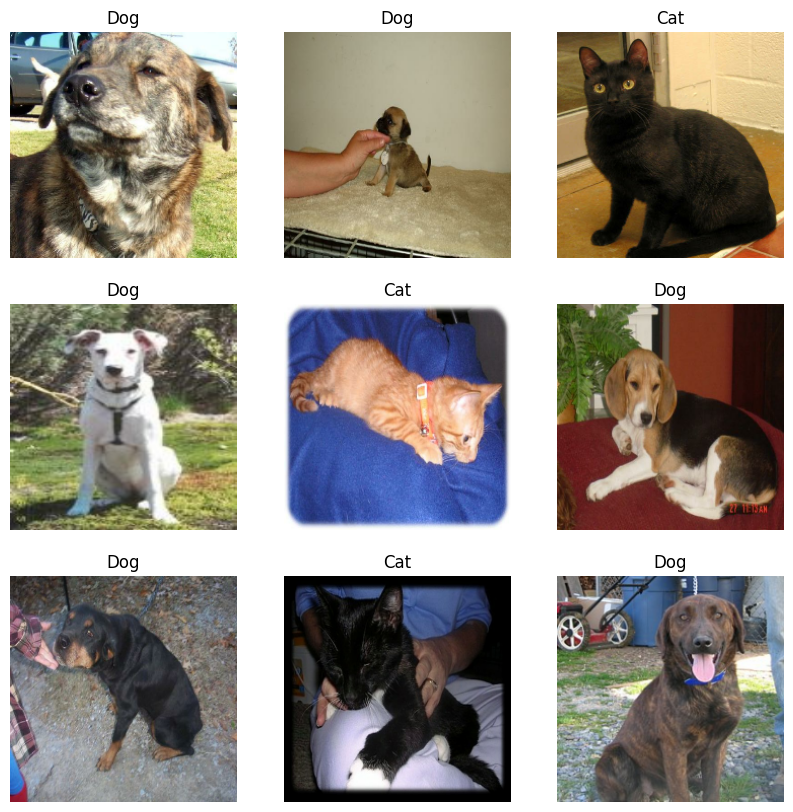

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

***Normalizing Images***

In [21]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

validation_dataset = validation_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

***Data Augmentation***

In [22]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2)

])

***Test Augmentation***

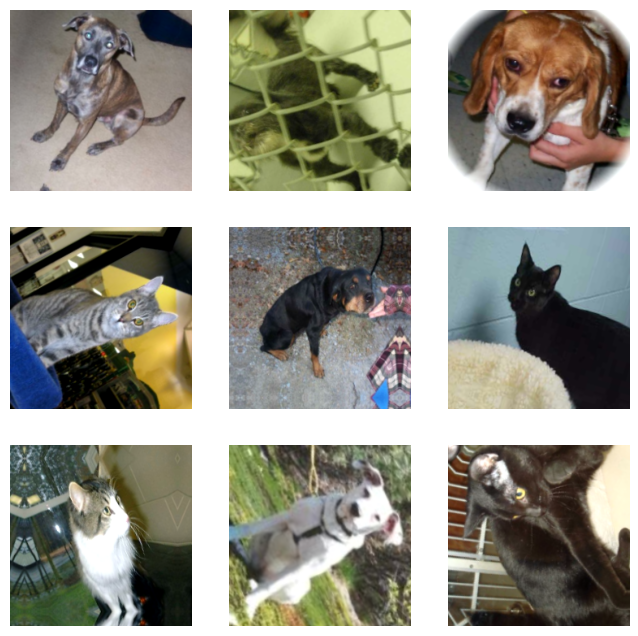

In [23]:
plt.figure(figsize=(8,8))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy())

        plt.axis("off")

plt.show()

Part 3: CNN Model Building

In [24]:
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(224,224,3)),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Part 4: ***Comiplation Phase***

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy','precision','recall','AUC']
)

Part 5: ***CNN Training Phase***

In [26]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - AUC: 0.5947 - accuracy: 0.5617 - loss: 0.6840 - precision: 0.5579 - recall: 0.5697 - val_AUC: 0.6829 - val_accuracy: 0.6329 - val_loss: 0.6450 - val_precision: 0.6399 - val_recall: 0.6451
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - AUC: 0.7185 - accuracy: 0.6632 - loss: 0.6183 - precision: 0.6709 - recall: 0.6330 - val_AUC: 0.7869 - val_accuracy: 0.7161 - val_loss: 0.5852 - val_precision: 0.7323 - val_recall: 0.7011
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - AUC: 0.7592 - accuracy: 0.6946 - loss: 0.5877 - precision: 0.7013 - recall: 0.6718 - val_AUC: 0.8256 - val_accuracy: 0.7471 - val_loss: 0.5271 - val_precision: 0.7833 - val_recall: 0.6987
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - AUC: 0.7978 - accuracy: 0.7258 - loss: 0.5476 - precision: 0.7303 - recall: 0.7109 - val_AUC: 0.8582 - val_accuracy: 0.7729 - val_loss: 0.4826 - val_precision: 0.7447 - val_recall: 0.8459
Epoch 5/10
625/625 ━━━━━

Part 6:***Model Evaluation and training***

In [27]:
print(history.history.keys())

dict_keys(['AUC', 'accuracy', 'loss', 'precision', 'recall', 'val_AUC', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


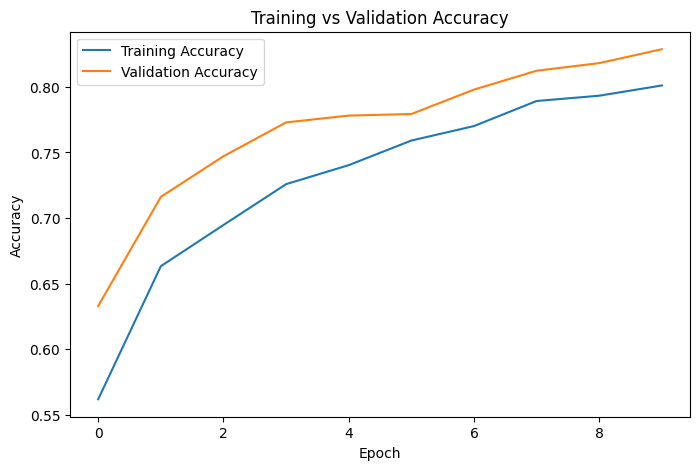

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

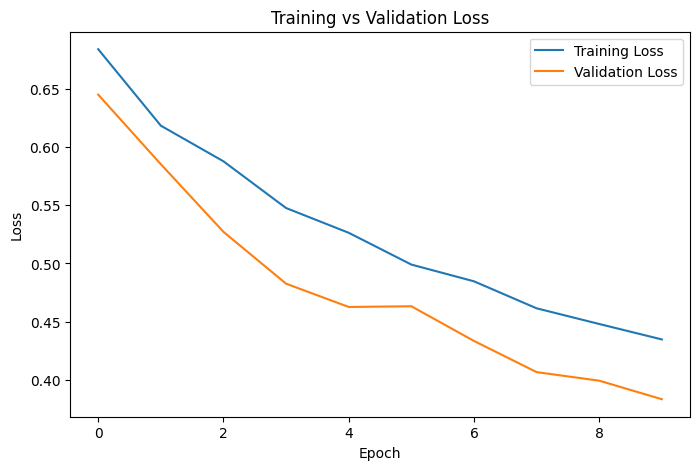

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [30]:
results = model.evaluate(validation_dataset, verbose=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - AUC: 0.9130 - accuracy: 0.8287 - loss: 0.3834 - precision: 0.8064 - recall: 0.8752


In [31]:
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

loss: 0.3834
compile_metrics: 0.8287


In [32]:
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[1905  537]
 [ 319 2237]]


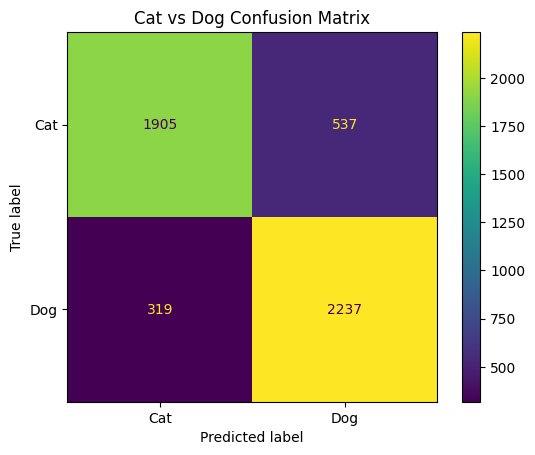

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Cat vs Dog Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Cat       0.86      0.78      0.82      2442
         Dog       0.81      0.88      0.84      2556

    accuracy                           0.83      4998
   macro avg       0.83      0.83      0.83      4998
weighted avg       0.83      0.83      0.83      4998



Actual: Cat
Predicted: Dog
Probability: 0.7241148


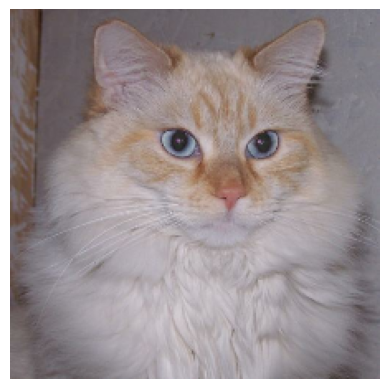

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

for images, labels in validation_dataset.take(1):

    image = images[0]
    true_label = labels[0].numpy()

    prediction = model.predict(
        tf.expand_dims(image, axis=0),
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        predicted_label = 1
    else:
        predicted_label = 0

    plt.imshow(image)
    plt.axis("off")

    print("Actual:", class_names[true_label])
    print("Predicted:", class_names[predicted_label])
    print("Probability:", prediction)

In [37]:
probability = float(prediction)

if probability >= 0.5:
    predicted_label = "Dog"
    confidence = probability * 100
else:
    predicted_label = "Cat"
    confidence = (1 - probability) * 100

print("Actual:", class_names[true_label])
print("Predicted:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

Actual: Cat
Predicted: Dog
Confidence: 72.41%


In [38]:
model.save("/content/cat_dog_cnn.keras")

In [39]:
import os

print(os.path.exists("/content/cat_dog_cnn.keras"))

True


In [40]:
model = tf.keras.models.load_model("/content/cat_dog_cnn.keras")